In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report
from xgboost import XGBClassifier 

import warnings
warnings.filterwarnings('ignore')

/home/hebo/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Load data and handle partitioned Parquet files cleanly
from pathlib import Path
import pyarrow.dataset as ds

print("Loading data...")

# Support both the notebook directory and the project root as the working directory.
data_dir = Path("home_credit_tables")
if not data_dir.exists():
    data_dir = Path("Documentation/8_Ai Model/home_credit_tables")

if not data_dir.exists():
    raise FileNotFoundError(f"Data directory not found: {data_dir.resolve()}")


def read_partitioned_table(table_name):
    table_path = data_dir / table_name
    dataset = ds.dataset(
        str(table_path),
        format="parquet",
        partitioning="hive"
    )
    return dataset.to_table().to_pandas()


# The root-level fact files contain the schema but no values for the columns
# written into the Hive partitions, so read only the actual partition files.
fact_path = data_dir / "fact_loan"
fact_files = sorted(fact_path.glob("NAME_CONTRACT_TYPE=*/*.parquet"))
if not fact_files:
    raise FileNotFoundError(f"No partitioned fact files found under: {fact_path.resolve()}")

df_fact = pd.concat(
    [pd.read_parquet(file_path, engine="pyarrow") for file_path in fact_files],
    ignore_index=True
)
df_dim = read_partitioned_table("dim_customer")

# Drop duplicates
# Keep the last row for each customer after all partitions have been loaded.
df_fact = df_fact.drop_duplicates(subset=["SK_ID_CURR"], keep="last")
df_dim = df_dim.drop_duplicates(subset=["SK_ID_CURR"], keep="last")

# Merge fact and dimension tables on SK_ID_CURR
df = pd.merge(df_fact, df_dim, on="SK_ID_CURR", how="inner", suffixes=("", "_dup"))

# Drop any duplicated suffix columns if they appear
df = df.loc[:, ~df.columns.str.endswith("_dup")]

print("Data loaded and merged successfully!")
print("Data shape:", df.shape)
print("loan_key non-null count:", df["loan_key"].notna().sum())
print("NAME_CONTRACT_TYPE values:", df["NAME_CONTRACT_TYPE"].dropna().unique())

Loading data...
Data loaded and merged successfully!
Data shape: (307511, 45)
loan_key non-null count: 307511
NAME_CONTRACT_TYPE values: ['Cash loans' 'Revolving loans']


In [3]:
# Display dataset info
df.info()

# Remove identifiers and surrogate keys
columns_to_drop = ['SK_ID_CURR', 'loan_key']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

print("\nData head:")
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 45 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   SK_ID_CURR                     307511 non-null  int32  
 1   TARGET                         307511 non-null  int32  
 2   DAYS_BIRTH                     307511 non-null  int32  
 3   AMT_INCOME_TOTAL               307511 non-null  float64
 4   AMT_CREDIT                     307511 non-null  float64
 5   AMT_ANNUITY                    307511 non-null  float64
 6   AMT_GOODS_PRICE                307511 non-null  float64
 7   DAYS_EMPLOYED                  252137 non-null  float64
 8   DTI                            307511 non-null  float64
 9   Annuity_to_Income              307511 non-null  float64
 10  LTV                            307233 non-null  float64
 11  Employed_to_Age                307511 non-null  float64
 12  Prev_App_Count                

,TARGET,DAYS_BIRTH,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_EMPLOYED,DTI,Annuity_to_Income,LTV,...,Annuity_vs_Historical_Payment,CODE_GENDER,FLAG_OWN_CAR,NAME_CONTRACT_TYPE,OCCUPATION_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,NAME_INCOME_TYPE,FLAG_OWN_REALTY
0,0,15612,308250.0,1305000.0,38281.5,1305000.0,1106.0,4.2336,0.1242,1.0000,...,1.3267,M,Y,Cash loans,Drivers,Secondary / secondary special,Civil marriage,House / apartment,Working,Y
1,0,21314,126000.0,698517.0,23215.5,603000.0,NaN,5.5438,0.1843,1.1584,...,2.1704,F,N,Cash loans,Retired,Lower secondary,Widow,House / apartment,Pensioner,Y
2,0,10960,157500.0,327024.0,21420.0,270000.0,1091.0,2.0763,0.1360,1.2112,...,3.3582,F,N,Cash loans,High skill tech staff,Secondary / secondary special,Separated,House / apartment,Working,Y
3,0,17231,180000.0,640080.0,29970.0,450000.0,3683.0,3.5560,0.1665,1.4224,...,2.2011,M,Y,Cash loans,Drivers,Secondary / secondary special,Married,House / apartment,Working,Y
4,0,23643,112500.0,819432.0,23958.0,684000.0,3326.0,7.2838,0.2130,1.1980,...,1.9347,F,N,Cash loans,Sales staff,Secondary / secondary special,Widow,House / apartment,Working,Y


Class counts:
 TARGET
0    282686
1     24825
Name: count, dtype: int64

Class percentage:
 TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


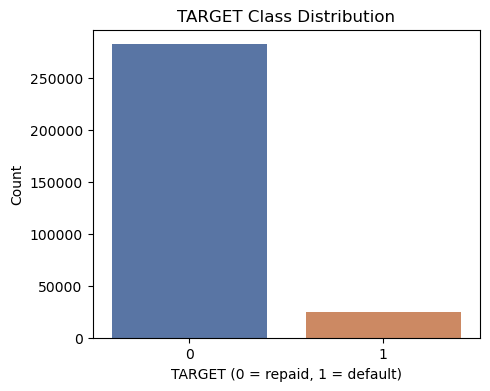


The minority class (defaults) is only about 8.07% of the data, which is why a model trained without addressing this will just learn to predict 'no default' most of the time.


In [4]:
target_counts = df['TARGET'].value_counts()
target_pct = df['TARGET'].value_counts(normalize=True) * 100

print("Class counts:\n", target_counts)
print("\nClass percentage:\n", target_pct.round(2))

plt.figure(figsize=(5, 4))
sns.barplot(x=target_counts.index, y=target_counts.values, palette=['#4C72B0', '#DD8452'])
plt.title('TARGET Class Distribution')
plt.xlabel('TARGET (0 = repaid, 1 = default)')
plt.ylabel('Count')
plt.xticks([0, 1])
plt.show()

print(f"\nThe minority class (defaults) is only about {target_pct[1]:.2f}% of the data, "
      "which is why a model trained without addressing this will just learn to predict "
      "'no default' most of the time.")

In [5]:
# Identify categorical columns
object_columns = df.select_dtypes(include=['object', 'category']).columns
print("Categorical Columns:", list(object_columns))

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=object_columns, drop_first=True)
print(f"Shape after encoding: {df_encoded.shape}")

Categorical Columns: ['CODE_GENDER', 'FLAG_OWN_CAR', 'NAME_CONTRACT_TYPE', 'OCCUPATION_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'NAME_INCOME_TYPE', 'FLAG_OWN_REALTY']
Shape after encoding: (307511, 78)


In [6]:
# Separate target and features
X = df_encoded.drop(columns=['TARGET'])
y = df_encoded['TARGET']

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (246008, 77)
Testing features shape: (61503, 77)


In [7]:
# Identify numerical columns for scaling
num_columns = X_train.select_dtypes(include=['int64', 'float64']).columns

# Initialize and apply StandardScaler
scaler = StandardScaler()
X_train[num_columns] = scaler.fit_transform(X_train[num_columns])
X_test[num_columns] = scaler.transform(X_test[num_columns])

print("Standardization applied successfully.")

Standardization applied successfully.


In [8]:
# Calculate weight to handle imbalanced data
pos_count = sum(y_train == 1)
neg_count = sum(y_train == 0)
balance_weight = neg_count / pos_count

print(f"Scale Pos Weight: {balance_weight:.2f}")

# Initialize XGBoost model
xgb_model = XGBClassifier(
    scale_pos_weight=balance_weight, 
    n_estimators=200,                
    max_depth=5,                     
    learning_rate=0.1,               
    subsample=0.8,                   
    random_state=42,
    n_jobs=-1                        
)

# Train the model
print("Training the XGBoost model...")
xgb_model.fit(X_train, y_train)
print("Model training completed!")

Scale Pos Weight: 11.39
Training the XGBoost model...
Model training completed!


XGBoost ROC-AUC Score: 0.7172



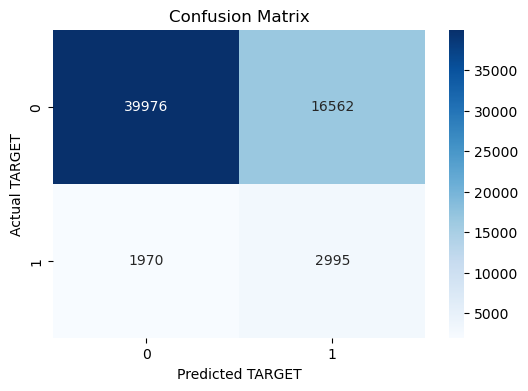

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.71      0.81     56538
           1       0.15      0.60      0.24      4965

    accuracy                           0.70     61503
   macro avg       0.55      0.66      0.53     61503
weighted avg       0.89      0.70      0.77     61503



In [9]:
# Generate predictions
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
y_pred = xgb_model.predict(X_test)

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"XGBoost ROC-AUC Score: {roc_auc:.4f}\n")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual TARGET')
plt.xlabel('Predicted TARGET')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))